In [32]:
# Import required libraries
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [33]:
# Download S&P 500 historical data
snp = yf.download('^GSPC', start='1900-01-01', auto_adjust=False, progress=False)

if isinstance(snp.columns, pd.MultiIndex):
    snp.columns = snp.columns.get_level_values(0)

display(snp.head())

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1927-12-30,17.660000,17.660000,17.660000,17.660000,17.660000,0
1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0


In [34]:
# Choose the best available price series for annual return calculations
print('Columns in snp DataFrame:', snp.columns)
close_col = 'Adj Close' if 'Adj Close' in snp.columns else 'Close'
if close_col not in snp.columns:
    raise ValueError("Neither 'Adj Close' nor 'Close' was found in the downloaded data.")

print('Using price column:', close_col)

Columns in snp DataFrame: Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Using price column: Adj Close


Mean annual return: 8.06%


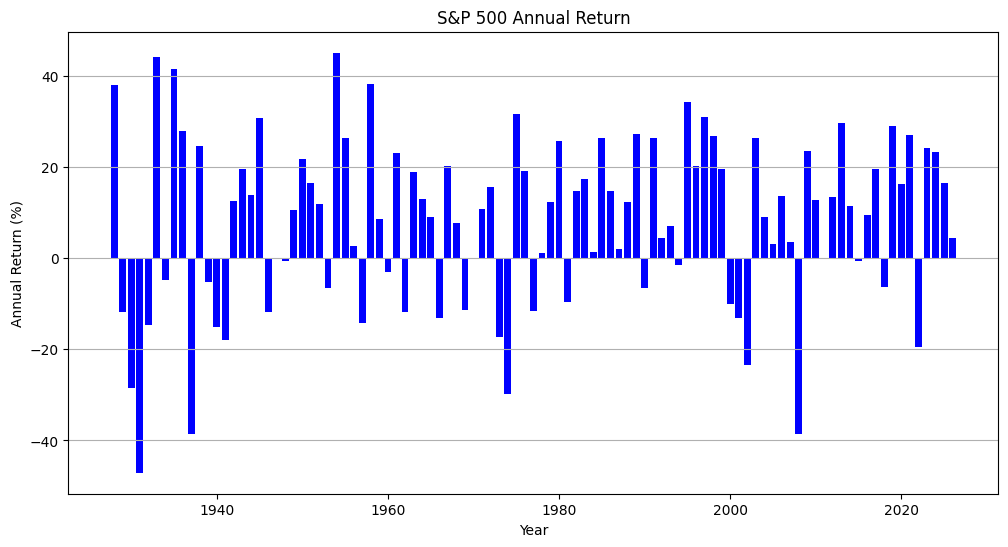

In [35]:
# Calculate annual returns from year-end prices and plot
annual_close = snp[close_col].resample('YE').last()
annual_return = annual_close.pct_change().dropna() * 100
mean_annual_return = annual_return.mean()
print(f'Mean annual return: {mean_annual_return:.2f}%')

plt.figure(figsize=(12, 6))
plt.bar(annual_return.index.year, annual_return.values, width=0.8, color='blue')
plt.title('S&P 500 Annual Return')
plt.xlabel('Year')
plt.ylabel('Annual Return (%)')
plt.grid(axis='y')
plt.show()

Mean annual log return: 6.06%


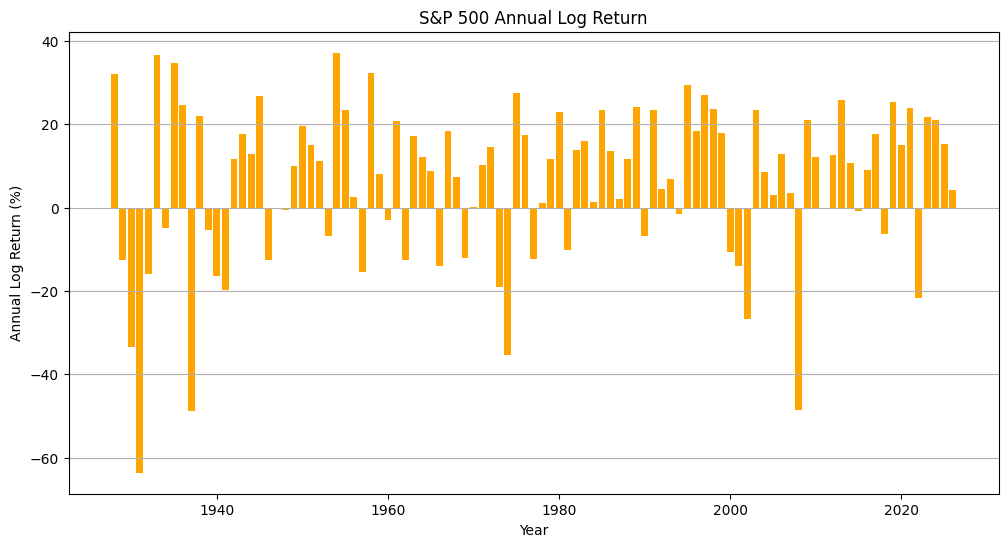

In [36]:
# Calculate annual log returns and plot
logged_annual_return = np.log(annual_close / annual_close.shift(1)).dropna()
mean_logged_annual_return = logged_annual_return.mean() * 100
print(f'Mean annual log return: {mean_logged_annual_return:.2f}%')

plt.figure(figsize=(12, 6))
plt.bar(logged_annual_return.index.year, logged_annual_return.values * 100, width=0.8, color='orange')
plt.title('S&P 500 Annual Log Return')
plt.xlabel('Year')
plt.ylabel('Annual Log Return (%)')
plt.grid(axis='y')
plt.show()

In [37]:
# Occam's razor summary: a few simple assumptions from the data
positive_year_frequency = (annual_return > 0).mean() * 100
annual_return_volatility = annual_return.std()
worst_year = annual_return.min()
best_year = annual_return.max()
cumulative_growth = (1 + annual_return / 100).cumprod()
drawdown = cumulative_growth / cumulative_growth.cummax() - 1
max_drawdown = drawdown.min() * 100

summary = pd.Series({
    'Positive year frequency (%)': positive_year_frequency,
    'Annual return volatility (%)': annual_return_volatility,
    'Best year (%)': best_year,
    'Worst year (%)': worst_year,
    'Max drawdown from annual compounding (%)': max_drawdown,
})

display(summary.round(2))

Positive year frequency (%)                 67.68
Annual return volatility (%)                18.87
Best year (%)                               45.02
Worst year (%)                             -47.07
Max drawdown from annual compounding (%)   -71.58
dtype: float64

### Simple assumptions supported by the annual data

- Long-run drift is positive: the index compounds over time and positive years should outnumber negative years.
- Short-run annual outcomes are noisy: annual return volatility is large relative to the mean.
- Tail losses shape compounding: the worst year and maximum drawdown matter disproportionately.

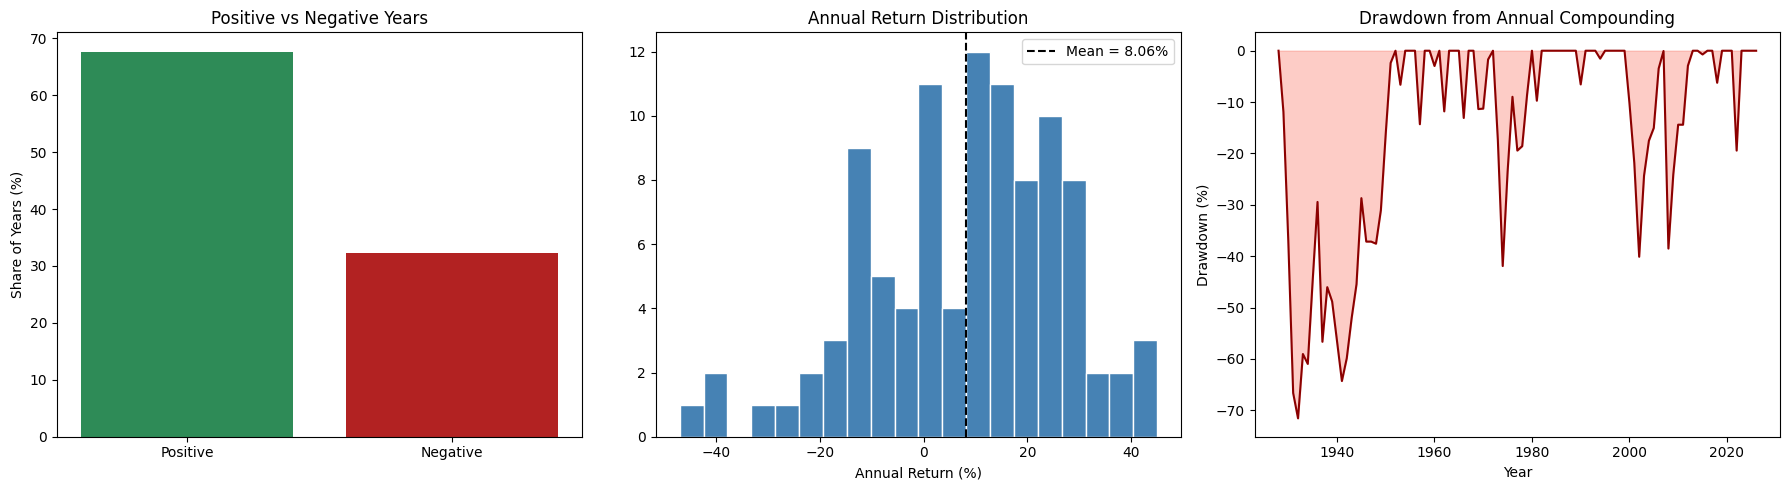

In [38]:
# Visual summary of the three assumptions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(['Positive', 'Negative'], [positive_year_frequency, 100 - positive_year_frequency], color=['seagreen', 'firebrick'])
axes[0].set_title('Positive vs Negative Years')
axes[0].set_ylabel('Share of Years (%)')

axes[1].hist(annual_return.values, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(mean_annual_return, color='black', linestyle='--', label=f'Mean = {mean_annual_return:.2f}%')
axes[1].set_title('Annual Return Distribution')
axes[1].set_xlabel('Annual Return (%)')
axes[1].legend()

axes[2].plot(drawdown.index.year, drawdown.values * 100, color='darkred')
axes[2].fill_between(drawdown.index.year, drawdown.values * 100, 0, color='salmon', alpha=0.4)
axes[2].set_title('Drawdown from Annual Compounding')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Drawdown (%)')

plt.tight_layout()
plt.show()

### Falsification checks

These are not proofs. They are simple ways to ask whether the annual data weakens or contradicts the three assumptions.

In [39]:
# Falsification checks for the simple assumptions
median_annual_return = annual_return.median()
signal_to_noise = mean_annual_return / annual_return_volatility if annual_return_volatility != 0 else np.nan

negative_log_returns = logged_annual_return[logged_annual_return < 0]
tail_cutoff = max(1, int(np.ceil(len(logged_annual_return) * 0.05)))
worst_tail = logged_annual_return.nsmallest(tail_cutoff)
tail_loss_share = np.nan
if len(negative_log_returns) > 0 and negative_log_returns.abs().sum() != 0:
    tail_loss_share = worst_tail.abs().sum() / negative_log_returns.abs().sum()

falsification_checks = pd.DataFrame([
    {
        'Assumption': 'Long-run drift is positive',
        'Metric': 'Positive-year frequency and central tendency',
        'Value': f"{positive_year_frequency:.2f}% positive years, mean {mean_annual_return:.2f}%, median {median_annual_return:.2f}%",
        'Would weaken assumption if': 'Positive years <= 50% or both mean and median <= 0',
        'Status': 'Not falsified' if (positive_year_frequency > 50) and ((mean_annual_return > 0) or (median_annual_return > 0)) else 'Potentially falsified',
    },
    {
        'Assumption': 'Short-run annual outcomes are noisy',
        'Metric': 'Signal-to-noise ratio = mean / volatility',
        'Value': f"{signal_to_noise:.2f}",
        'Would weaken assumption if': 'Signal-to-noise >= 1, meaning the average dominates dispersion',
        'Status': 'Not falsified' if pd.notna(signal_to_noise) and signal_to_noise < 1 else 'Potentially falsified',
    },
    {
        'Assumption': 'Tail losses shape compounding',
        'Metric': 'Share of all negative log-return magnitude coming from worst 5% of years',
        'Value': f"{tail_loss_share * 100:.2f}%" if pd.notna(tail_loss_share) else 'N/A',
        'Would weaken assumption if': 'Worst 5% of years contribute less than 25% of all negative log-return magnitude',
        'Status': 'Not falsified' if pd.notna(tail_loss_share) and tail_loss_share >= 0.25 else 'Potentially falsified',
    },
])

display(falsification_checks)

,Assumption,Metric,Value,Would weaken assumption if,Status
0,Long-run drift is positive,Positive-year frequency and central tendency,"67.68% positive years, mean 8.06%, median 11.39%",Positive years <= 50% or both mean and median ...,Not falsified
1,Short-run annual outcomes are noisy,Signal-to-noise ratio = mean / volatility,0.43,"Signal-to-noise >= 1, meaning the average domi...",Not falsified
2,Tail losses shape compounding,Share of all negative log-return magnitude com...,44.89%,Worst 5% of years contribute less than 25% of ...,Not falsified


In [40]:
# Optional compact verdicts
for _, row in falsification_checks.iterrows():
    print(f"{row['Assumption']}: {row['Status']}")
    print(f"  Metric: {row['Value']}")
    print(f"  Falsifier: {row['Would weaken assumption if']}")


Long-run drift is positive: Not falsified
  Metric: 67.68% positive years, mean 8.06%, median 11.39%
  Falsifier: Positive years <= 50% or both mean and median <= 0
Short-run annual outcomes are noisy: Not falsified
  Metric: 0.43
  Falsifier: Signal-to-noise >= 1, meaning the average dominates dispersion
Tail losses shape compounding: Not falsified
  Metric: 44.89%
  Falsifier: Worst 5% of years contribute less than 25% of all negative log-return magnitude
